# Projeto PCD: K-means 1D (naive) com Paralelização Progressiva

## Algoritmo K-Means (Sequencial)

In [ ]:
%%writefile kmeans_1d_naive.c

/* kmeans_1d_naive.c
   K-means 1D (C99), implementação "naive":
   - Lê X (N linhas, 1 coluna) e C_init (K linhas, 1 coluna) de CSVs sem cabeçalho.
   - Itera assignment + update até max_iter ou variação relativa do SSE < eps.
   - Salva (opcional) assign (N linhas) e centróides finais (K linhas).

   Compilar: gcc -O2 -std=c99 kmeans_1d_naive.c -o kmeans_1d_naive -lm
   Uso:      ./kmeans_1d_naive dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] [assign.csv] [centroids.csv]
*/

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>

/* ---------- util CSV 1D: cada linha tem 1 número ---------- */
static int count_rows(const char *path){
    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); exit(1); }
    int rows=0; char line[8192];
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(!only_ws) rows++;
    }
    fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path, int *n_out){
    int R = count_rows(path);
    if(R<=0){ fprintf(stderr,"Arquivo vazio: %s\n", path); exit(1); }
    double *A = (double*)malloc((size_t)R * sizeof(double));
    if(!A){ fprintf(stderr,"Sem memoria para %d linhas\n", R); exit(1); }

    FILE *f = fopen(path, "r");
    if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); free(A); exit(1); }

    char line[8192];
    int r=0;
    while(fgets(line,sizeof(line),f)){
        int only_ws=1;
        for(char *p=line; *p; p++){
            if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws=0; break; }
        }
        if(only_ws) continue;

        /* aceita vírgula/ponto-e-vírgula/espaco/tab, pega o primeiro token numérico */
        const char *delim = ",; \t";
        char *tok = strtok(line, delim);
        if(!tok){ fprintf(stderr,"Linha %d sem valor em %s\n", r+1, path); free(A); fclose(f); exit(1); }
        A[r] = atof(tok);
        r++;
        if(r>R) break;
    }
    fclose(f);
    *n_out = R;
    return A;
}

static void write_assign_csv(const char *path, const int *assign, int N){
    if(!path) return;
    FILE *f = fopen(path, "w");
    if(!f){ fprintf(stderr,"Erro ao abrir %s para escrita\n", path); return; }
    for(int i=0;i<N;i++) fprintf(f, "%d\n", assign[i]);
    fclose(f);
}

static void write_centroids_csv(const char *path, const double *C, int K){
    if(!path) return;
    FILE *f = fopen(path, "w");
    if(!f){ fprintf(stderr,"Erro ao abrir %s para escrita\n", path); return; }
    for(int c=0;c<K;c++) fprintf(f, "%.6f\n", C[c]);
    fclose(f);
}

/* ---------- k-means 1D ---------- */
/* assignment: para cada X[i], encontra c com menor (X[i]-C[c])^2 */
static double assignment_step_1d(const double *X, const double *C, int *assign, int N, int K){
    double sse = 0.0;
    for(int i=0;i<N;i++){
        int best = -1;
        double bestd = 1e300;
        for(int c=0;c<K;c++){
            double diff = X[i] - C[c];
            double d = diff*diff;
            if(d < bestd){ bestd = d; best = c; }
        }
        assign[i] = best;
        sse += bestd;
    }
    return sse;
}

/* update: média dos pontos de cada cluster (1D)
   se cluster vazio, copia X[0] (estratégia naive) */
static void update_step_1d(const double *X, double *C, const int *assign, int N, int K){
    double *sum = (double*)calloc((size_t)K, sizeof(double));
    int *cnt = (int*)calloc((size_t)K, sizeof(int));
    if(!sum || !cnt){ fprintf(stderr,"Sem memoria no update\n"); exit(1); }

    for(int i=0;i<N;i++){
        int a = assign[i];
        cnt[a] += 1;
        sum[a] += X[i];
    }
    for(int c=0;c<K;c++){
        if(cnt[c] > 0) C[c] = sum[c] / (double)cnt[c];
        else           C[c] = X[0]; /* simples: cluster vazio recebe o primeiro ponto */
    }
    free(sum); free(cnt);
}

static void kmeans_1d(const double *X, double *C, int *assign,
                      int N, int K, int max_iter, double eps,
                      int *iters_out, double *sse_out)
{
    double prev_sse = 1e300;
    double sse = 0.0;
    int it;
    for(it=0; it<max_iter; it++){
        sse = assignment_step_1d(X, C, assign, N, K);
        //printf("Iteracao %d: SSE = %.6f\n", it+1, sse);

        /* parada por variação relativa do SSE */
        double rel = fabs(sse - prev_sse) / (prev_sse > 0.0 ? prev_sse : 1.0);
        if(rel < eps){ it++; break; }
        update_step_1d(X, C, assign, N, K);
        prev_sse = sse;
    }
    *iters_out = it;
    *sse_out = sse;
}

/* ---------- main ---------- */
int main(int argc, char **argv){
    if(argc < 3){
        printf("Uso: %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] [assign.csv] [centroids.csv]\n", argv[0]);
        printf("Obs: arquivos CSV com 1 coluna (1 valor por linha), sem cabeçalho.\n");
        return 1;
    }
    const char *pathX = argv[1];
    const char *pathC = argv[2];
    int max_iter = (argc>3)? atoi(argv[3]) : 50;
    double eps   = (argc>4)? atof(argv[4]) : 1e-4;
    const char *outAssign   = (argc>5)? argv[5] : NULL;
    const char *outCentroid = (argc>6)? argv[6] : NULL;

    if(max_iter <= 0 || eps <= 0.0){
        fprintf(stderr,"Parâmetros inválidos: max_iter>0 e eps>0\n");
        return 1;
    }

    int N=0, K=0;
    double *X = read_csv_1col(pathX, &N);
    double *C = read_csv_1col(pathC, &K);
    int *assign = (int*)malloc((size_t)N * sizeof(int));
    if(!assign){ fprintf(stderr,"Sem memoria para assign\n"); free(X); free(C); return 1; }

    clock_t t0 = clock();
    int iters = 0; double sse = 0.0;
    kmeans_1d(X, C, assign, N, K, max_iter, eps, &iters, &sse);
    clock_t t1 = clock();
    double ms = 1000.0 * (double)(t1 - t0) / (double)CLOCKS_PER_SEC;

    printf("K-means 1D (naive)\n");
    printf("N=%d K=%d max_iter=%d eps=%g\n", N, K, max_iter, eps);
    printf("Iterações: %d | SSE final: %.6f | Tempo: %.6f ms\n", iters, sse, ms);

    write_assign_csv(outAssign, assign, N);
    write_centroids_csv(outCentroid, C, K);

    free(assign); free(X); free(C);
    return 0;
}

Writing kmeans_1d_naive.c


## Dados

In [ ]:
import numpy as np

for N in [10_000, 100_000, 1_000_000]:
    X = np.random.uniform(low=0, high=100, size=N)
    np.savetxt(f'dados_{N}.csv', X, fmt='%.6f')
    print(f'Arquivo dados_{N}.csv criado!')

Arquivo dados_10000.csv criado!
Arquivo dados_100000.csv criado!
Arquivo dados_1000000.csv criado!


## Centróides Iniciais

In [ ]:
%%writefile centroides_iniciais.csv

10
30
60
90

Writing centroides_iniciais.csv


## Etapa 3 — MPI

## Algoritmo K-Means (MPI)

In [ ]:
%%writefile kmeans_1d_mpi.c

/* kmeans_1d_mpi.c
K-means 1D (C99) com MPI:
- Lê X (N linhas, 1 coluna) e C_init (K linhas, 1 coluna) de CSVs sem cabeça
- Itera assignment + update até max_iter ou variação relativa do SSE < eps.
- Salva (opcional) assign (N linhas) e centróides finais (K linhas).

Compilar: mpicc -O2 -std=c99 kmeans_1d_mpi.c -o kmeans_1d_mpi -lm
Uso: mpirun -np <num_procs> ./kmeans_1d_mpi dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] [out_assign.csv] [out_centroids.csv]
*/

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <time.h>
#include <float.h>
#include <string.h>
#include <mpi.h>

/* ---------- util CSV 1D: cada linha tem 1 número ---------- */
static int count_rows(const char *path){
	FILE *f = fopen(path, "r");
	if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); exit(1); }
	int rows = 0;
	char line[8192];
	while(fgets(line, sizeof(line), f)){
		int only_ws = 1;
		for(char *p = line; *p; p++){
			if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws = 0; break; }
		}
		if(!only_ws) rows++;
	}
	fclose(f);
	return rows;
}

static double *read_csv_1col(const char *path, int *n_out){
	int R = count_rows(path);
	if(R<=0){ fprintf(stderr,"Arquivo vazio: %s\n", path); exit(1); }
	double *A = (double*)malloc((size_t)R * sizeof(double));
	if(!A){ fprintf(stderr,"Sem memoria para %d linhas\n", R); exit(1); }
	FILE *f = fopen(path, "r");
	if(!f){ fprintf(stderr,"Erro ao abrir %s\n", path); free(A); exit(1); }
	char line[8192];
	int r = 0;
	const char *delim = ",; \t\r\n";
	while(fgets(line, sizeof(line), f)){
		int only_ws = 1;
		for(char *p = line; *p; p++){
			if(*p!=' ' && *p!='\t' && *p!='\n' && *p!='\r'){ only_ws = 0; break; }
		}
		if(only_ws) continue;
		char *tok = strtok(line, delim);
		if(!tok){ fprintf(stderr,"Linha %d sem valor em %s\n", r+1, path); free(A); fclose(f); exit(1); }
		A[r] = atof(tok);
		r++;
		if(r >= R) break;
	}
	fclose(f);
	*n_out = r;
	return A;
}

static void write_assign_csv(const char *path, const int *assign, int N){
	if(!path) return;
	FILE *f = fopen(path, "w");
	if(!f){ fprintf(stderr,"Erro ao abrir %s para escrita\n", path); return; }
	for(int i=0;i<N;i++){
		fprintf(f, "%d\n", assign[i]);
	}
	fclose(f);
}

static void write_centroids_csv(const char *path, const double *C, int K){
	if(!path) return;
	FILE *f = fopen(path, "w");
	if(!f){ fprintf(stderr,"Erro ao abrir %s para escrita\n", path); return; }
	for(int i=0;i<K;i++){
		fprintf(f, "%.6f\n", C[i]);
	}
	fclose(f);
}

// Forward declarations for K-means steps
static double assign_step_1d(const double *local_X, double *C, int *local_assign, int local_N, int K);
static void update_step_1d(const double *local_X, const int *local_assign, double *C, int local_N, int K);

static void kmeans_1d_mpi(
	double *X, double *C, int *assign, // Full data/centroids/assignments (only on root for X, assign)
	int N, int K, // Global N, K
	int max_iter, double eps,
	int *iters_out, double *sse_out, // Output iteration count and final SSE
	int rank, int num_procs // MPI rank and size
) {
	double prev_sse = 1e300;
	double sse = 0.0;
	int it;

	// Determine local data sizes and displacements
	int *sendcounts_X = NULL;
	int *displs_X = NULL;
	int local_N;
	double *local_X = NULL;
	int *local_assign = NULL;

	if (rank == 0) {
		sendcounts_X = (int*)malloc(num_procs * sizeof(int));
		displs_X = (int*)malloc(num_procs * sizeof(int));
		int remainder = N % num_procs;
		int current_displ = 0;
		for (int i = 0; i < num_procs; ++i) {
			sendcounts_X[i] = N / num_procs + (i < remainder ? 1 : 0);
			displs_X[i] = current_displ;
			current_displ += sendcounts_X[i];
		}
	}

	MPI_Scatter(sendcounts_X, 1, MPI_INT, &local_N, 1, MPI_INT, 0, MPI_COMM_WORLD);
	local_X = (double*)malloc(local_N * sizeof(double));
	local_assign = (int*)malloc(local_N * sizeof(int));
	if (!local_X || !local_assign) {
		fprintf(stderr, "Rank %d: Sem memoria para dados locais.\n", rank); MPI_Abort(MPI_COMM_WORLD, 1);
	}

	// Scatter X data
	MPI_Scatterv(X, sendcounts_X, displs_X, MPI_DOUBLE, local_X, local_N, MPI_DOUBLE, 0, MPI_COMM_WORLD);

	// Broadcast initial centroids
	MPI_Bcast(C, K, MPI_DOUBLE, 0, MPI_COMM_WORLD);

	for(it=0; it < max_iter; ++it){
		// Perform assignment step on local data and calculate local SSE
		double local_sse = assign_step_1d(local_X, C, local_assign, local_N, K);

		// Sum all local SSEs to get global SSE
		MPI_Allreduce(&local_sse, &sse, 1, MPI_DOUBLE, MPI_SUM, MPI_COMM_WORLD);

		// Check for convergence (relative change in SSE)
		double rel = fabs((prev_sse - sse) / (prev_sse != 0.0 ? prev_sse : 1.0));
		if(rel < eps){ it++; break; }

		// Update centroids based on local assignments, then synchronize
		update_step_1d(local_X, local_assign, C, local_N, K);

		prev_sse = sse;
	}

	*iters_out = it;
	*sse_out = sse;

	// Gather all local assignments to reconstruct the global assignment array (only on rank 0)
	if (rank == 0) {
		MPI_Gatherv(local_assign, local_N, MPI_INT, assign, sendcounts_X, displs_X, MPI_INT, 0, MPI_COMM_WORLD);
	} else {
		MPI_Gatherv(local_assign, local_N, MPI_INT, NULL, NULL, NULL, MPI_INT, 0, MPI_COMM_WORLD);
	}

	free(local_X);
	free(local_assign);
	if (rank == 0) {
		free(sendcounts_X);
		free(displs_X);
	}
}

/* ---------- Parallel assign_step_1d ---------- */
// Each process assigns its local data points to the nearest centroid
// and calculates its local SSE.
static double assign_step_1d(const double *local_X, double *C, int *local_assign, int local_N, int K)
{
	double local_sse = 0.0;
	for(int i=0; i<local_N; ++i){
		double x_val = local_X[i];
		double min_dist_sq = DBL_MAX;
		int best_c = -1;

		for(int c=0; c<K; ++c){
			double dist_sq = (x_val - C[c]) * (x_val - C[c]);
			if(dist_sq < min_dist_sq){
				min_dist_sq = dist_sq;
				best_c = c;
			}
		}
		local_assign[i] = best_c;
		local_sse += min_dist_sq;
	}
	return local_sse;
}

/* ---------- Parallel update_step_1d ---------- */
// Each process calculates local sums and counts for centroids,
// then uses MPI_Allreduce to get global sums and counts, and updates centroids.
static void update_step_1d(const double *local_X, const int *local_assign, double *C, int local_N, int K)
{
	double *local_sum = (double*)calloc(K, sizeof(double));
	int *local_cnt = (int*)calloc(K, sizeof(int));

	if(!local_sum || !local_cnt){ fprintf(stderr,"Sem memoria para sum/cnt locais\n"); MPI_Abort(MPI_COMM_WORLD, 1); }

	// Calculate local sums and counts for each centroid
	for(int i=0; i<local_N; ++i){
		int a = local_assign[i];
		if(a >= 0 && a < K){
			local_cnt[a] += 1;
			local_sum[a] += local_X[i];
		}
	}

	// Allreduce to get global sums and counts
	double *global_sum = (double*)malloc(K * sizeof(double));
	int *global_cnt = (int*)malloc(K * sizeof(int));
	if(!global_sum || !global_cnt){ fprintf(stderr,"Sem memoria para sum/cnt globais\n"); MPI_Abort(MPI_COMM_WORLD, 1); }

	MPI_Allreduce(local_sum, global_sum, K, MPI_DOUBLE, MPI_SUM, MPI_COMM_WORLD);
	MPI_Allreduce(local_cnt, global_cnt, K, MPI_INT, MPI_SUM, MPI_COMM_WORLD);

	// Update centroids
	for(int c=0; c<K; ++c){
		if(global_cnt[c] > 0) C[c] = global_sum[c] / (double)global_cnt[c];
		// Handling empty clusters: in a distributed setting, this is tricky.
		// For simplicity, we'll keep the old centroid if a cluster becomes empty.
		// More robust solutions might re-initialize empty clusters.
	}

	free(local_sum);
	free(local_cnt);
	free(global_sum);
	free(global_cnt);
}

/* ---------- main ---------- */
int main(int argc, char **argv){
	MPI_Init(&argc, &argv);

	int rank, num_procs;
	MPI_Comm_rank(MPI_COMM_WORLD, &rank);
	MPI_Comm_size(MPI_COMM_WORLD, &num_procs);

	if(argc < 3){
		if (rank == 0) {
			printf("Uso: %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] [out_assign.csv] [out_centroids.csv]\n", argv[0]);
			printf("Obs: arquivos CSV com 1 coluna (1 valor por linha), sem cabecalho\n");
		}
		MPI_Finalize();
		return 1;
	}
	const char *pathX = argv[1];
	const char *pathC = argv[2];
	int max_iter = (argc>3)? atoi(argv[3]) : 50;
	double eps = (argc>4)? atof(argv[4]) : 1e-4;
	const char *outAssign = (argc>5)? argv[5] : NULL;
	const char *outCentroid = (argc>6)? argv[6] : NULL;

	if(max_iter <= 0 || eps <= 0.0){
		if (rank == 0) {
			fprintf(stderr,"Parâmetros inválidos: max_iter>0 e eps>0\n");
		}
		MPI_Finalize();
		return 1;
	}

	int N=0, K=0;
	double *X = NULL;
	double *C = NULL;
	int *assign = NULL;

	// Only rank 0 reads the full data and initial centroids
	if (rank == 0) {
		X = read_csv_1col(pathX, &N);
		C = read_csv_1col(pathC, &K);
		if(!X || !C){ fprintf(stderr,"Erro ao ler arquivos de entrada\n"); free(X); free(C); MPI_Finalize(); return 1; }
		assign = (int*)malloc((size_t)N * sizeof(int));
		if(!assign){ fprintf(stderr,"Sem memoria para assign\n"); free(X); free(C); MPI_Finalize(); return 1; }
	} else {
		// Other ranks need to know N and K for data distribution setup
		// We can broadcast N and K after rank 0 reads them.
		// For C, all ranks need a buffer for MPI_Bcast.
		// N will be inferred by calculating total elements from sendcounts_X and displs_X
		// K needs to be determined for C allocation on other ranks.
		// We will get K from pathC, assuming all processes can call count_rows.
		K = count_rows(pathC);
		C = (double*)malloc((size_t)K * sizeof(double));
		if (!C) { fprintf(stderr, "Rank %d: Sem memoria para centroides.\n", rank); MPI_Abort(MPI_COMM_WORLD, 1); }
	}

	// Broadcast N and K to all processes (N is needed for sendcounts/displs calculations if not done on root)
	// K is already determined by counting rows, but N needs explicit broadcast.
	MPI_Bcast(&N, 1, MPI_INT, 0, MPI_COMM_WORLD);

	MPI_Barrier(MPI_COMM_WORLD); // Ensure all processes have N and K and C buffer is allocated before kmeans_1d_mpi

	MPI_Wtime(); // Start timing after file I/O
	double t0 = MPI_Wtime();
	int iters = 0; double sse = 0.0;

	kmeans_1d_mpi(X, C, assign, N, K, max_iter, eps, &iters, &sse, rank, num_procs);

	double t1 = MPI_Wtime();
	double ms = 1000.0 * (t1 - t0);

	if (rank == 0) {
		printf("K-means 1D (MPI)\n");
		printf("N=%d K=%d max_iter=%d eps=%g\n", N, K, max_iter, eps);
		printf("Iterações: %d | SSE final: %.6f | Tempo: %.1f ms\n", iters, sse, ms);

		write_assign_csv(outAssign, assign, N);
		write_centroids_csv(outCentroid, C, K);
		free(assign);
		free(X);
	}
	free(C);

	MPI_Finalize();
	return 0;
}


Writing kmeans_1d_mpi.c


## Resultados (N = 10k, 100k e 1M)

In [ ]:
%%bash
gcc -O2 -std=c99 kmeans_1d_naive.c -o kmeans_1d_naive -lm
mpicc -O2 -std=c99 kmeans_1d_mpi.c -o kmeans_1d_mpi -lm

## Sequencial


In [ ]:
!./kmeans_1d_naive dados_10000.csv centroides_iniciais.csv

K-means 1D (naive)
N=10000 K=4 max_iter=50 eps=0.0001
Iterações: 17 | SSE final: 515936.696329 | Tempo: 1.149000 ms


In [ ]:
!./kmeans_1d_naive dados_100000.csv centroides_iniciais.csv

K-means 1D (naive)
N=100000 K=4 max_iter=50 eps=0.0001
Iterações: 15 | SSE final: 5188818.902154 | Tempo: 10.341000 ms


In [ ]:
!./kmeans_1d_naive dados_1000000.csv centroides_iniciais.csv

K-means 1D (naive)
N=1000000 K=4 max_iter=50 eps=0.0001
Iterações: 16 | SSE final: 52089092.828104 | Tempo: 110.460000 ms


## MPI

In [ ]:
%%bash
mpirun --allow-run-as-root --oversubscribe -np 2 ./kmeans_1d_mpi dados_10000.csv centroides_iniciais.csv 50 1e-4 mpi_out_assign10k.csv mpi_out_centroids10k.csv

K-means 1D (MPI)
N=10000 K=4 max_iter=50 eps=0.0001
Iterações: 17 | SSE final: 515936.696329 | Tempo: 1.3 ms


In [ ]:
%%bash
mpirun --allow-run-as-root --oversubscribe -np 4 ./kmeans_1d_mpi dados_100000.csv centroides_iniciais.csv 50 1e-4 mpi_out_assign100k.csv mpi_out_centroids100k.csv

K-means 1D (MPI)
N=100000 K=4 max_iter=50 eps=0.0001
Iterações: 15 | SSE final: 5188818.902154 | Tempo: 11.4 ms


In [ ]:
%%bash
mpirun --allow-run-as-root --oversubscribe -np 8 ./kmeans_1d_mpi dados_1000000.csv centroides_iniciais.csv 50 1e-4 mpi_out_assign1M.csv mpi_out_centroids1M.csv

K-means 1D (MPI)
N=1000000 K=4 max_iter=50 eps=0.0001
Iterações: 16 | SSE final: 52089092.828105 | Tempo: 165.6 ms


## Gráficos


Sumário de Performance K-means 1D (Sequencial vs MPI)
N          K     Iterações  SSE Final          Tempo (ms)      Tipo       Processos 
--------------------------------------------------------------------------------
10000      4     17         515936.6963        1.08            Sequencial N/A       
10000      4     17         515936.6963        1.30            MPI        2         
100000     4     15         5188818.9022       9.61            Sequencial N/A       
100000     4     15         5188818.9022       11.30           MPI        4         
1000000    4     16         52089092.8281      121.50          Sequencial N/A       
1000000    4     16         52089092.8281      176.50          MPI        8         


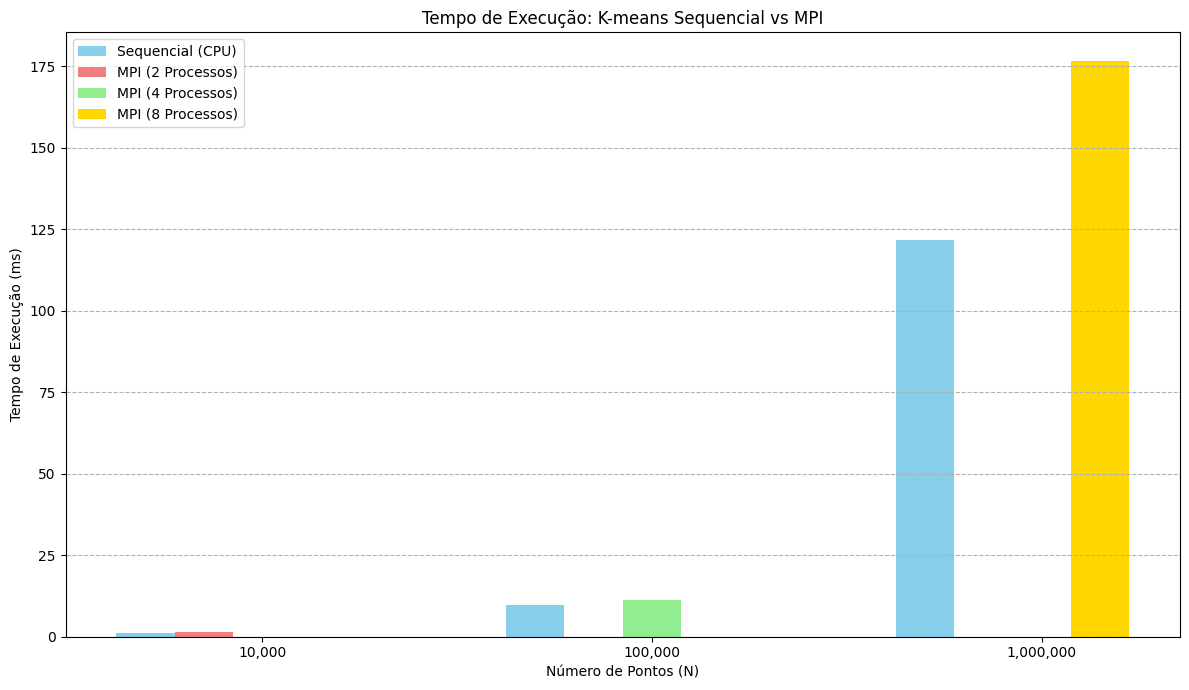

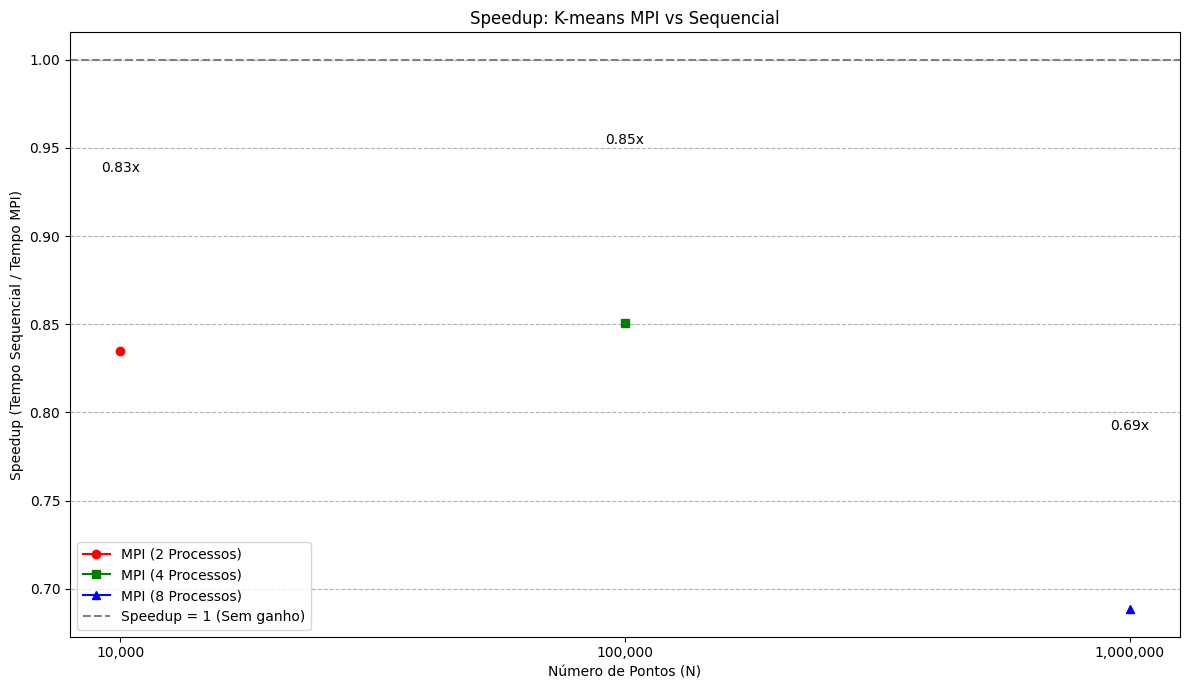

In [ ]:
import matplotlib.pyplot as plt
import re
import numpy as np
import os
import subprocess

def _run_cmd_capture_output(command):
    """Executes a shell command and captures its stdout."""
    try:
        result = subprocess.run(command, shell=True, capture_output=True, text=True, check=False, timeout=300)
        if result.returncode != 0 and "Error" in result.stderr: # Check stderr for explicit errors
            print(f"Warning: Command '{command}' failed with error: {result.stderr.strip()}")
        return result.stdout
    except subprocess.TimeoutExpired:
        print(f"Warning: Command '{command}' timed out after 300 seconds.")
        return "TIMEOUT"
    except Exception as e:
        print(f"Warning: An error occurred executing '{command}': {e}")
        return f"ERROR: {e}"

def parse_kmeans_output(output_str):
    """Parses the standard output from a K-means execution and extracts metrics."""
    metrics = {}

    # Common patterns for N, K, max_iter, eps, iterations, SSE, Time
    n_pattern = r'N=(\d+)'
    k_pattern = r'K=(\d+)'
    max_iter_pattern = r'max_iter=(\d+)'
    eps_pattern = r'eps=([\d.]+e?[+\-]?\d*)'
    iters_pattern = r'Iterações: (\d+)'
    sse_pattern = r'SSE final: ([\d.]+)'
    time_pattern = r'Tempo: ([\d.]+) ms'

    # Extract common metrics
    match_n = re.search(n_pattern, output_str)
    match_k = re.search(k_pattern, output_str)
    match_max_iter = re.search(max_iter_pattern, output_str)
    match_eps = re.search(eps_pattern, output_str)
    match_iters = re.search(iters_pattern, output_str)
    match_sse = re.search(sse_pattern, output_str)
    match_time = re.search(time_pattern, output_str)

    if match_n: metrics['N'] = int(match_n.group(1))
    if match_k: metrics['K'] = int(match_k.group(1))
    if match_max_iter: metrics['max_iter'] = int(match_max_iter.group(1))
    if match_eps: metrics['eps'] = float(match_eps.group(1))
    if match_iters: metrics['iterations'] = int(match_iters.group(1))
    if match_sse: metrics['sse'] = float(match_sse.group(1))
    if match_time: metrics['time_ms'] = float(match_time.group(1))

    return metrics

def collect_results():
    """Collects results from sequential and MPI K-means execution cells."""
    results = {
        'sequential': {},
        'mpi': {}
    }

    datasets = [10_000, 100_000, 1_000_000]
    mpi_procs_map = {10_000: 2, 100_000: 4, 1_000_000: 8}

    for N in datasets:
        # --- Sequential K-means ---
        seq_cmd = f"./kmeans_1d_naive dados_{N}.csv centroides_iniciais.csv"
        seq_output = _run_cmd_capture_output(seq_cmd)
        seq_metrics = parse_kmeans_output(seq_output)
        if seq_metrics: # Only store if parsing was successful
            results['sequential'][N] = seq_metrics
        else:
            print(f"Could not parse sequential output for N={N}:\n{seq_output}")

        # --- MPI K-means ---
        num_procs = mpi_procs_map.get(N)
        if num_procs:
            mpi_cmd = f"mpirun --allow-run-as-root --oversubscribe -np {num_procs} ./kmeans_1d_mpi dados_{N}.csv centroides_iniciais.csv 50 1e-4 mpi_out_assign{N}.csv mpi_out_centroids{N}.csv"
            mpi_output = _run_cmd_capture_output(mpi_cmd)
            mpi_metrics = parse_kmeans_output(mpi_output)
            if mpi_metrics: # Only store if parsing was successful
                mpi_metrics['num_procs'] = num_procs
                if N not in results['mpi']:
                    results['mpi'][N] = {}
                results['mpi'][N][num_procs] = mpi_metrics
            else:
                print(f"Could not parse MPI output for N={N}, procs={num_procs}:\n{mpi_output}")

    return results

def create_summary_table(results):
    """Prints a formatted table summarizing the performance metrics."""
    print("\n" + "="*80)
    print("Sumário de Performance K-means 1D (Sequencial vs MPI)")
    print("="*80)

    header = ["N", "K", "Iterações", "SSE Final", "Tempo (ms)", "Tipo", "Processos"]
    print(f"{header[0]:<10} {header[1]:<5} {header[2]:<10} {header[3]:<18} {header[4]:<15} {header[5]:<10} {header[6]:<10}")
    print("-"*80)

    sorted_N = sorted(results['sequential'].keys())

    for N in sorted_N:
        # Sequential data
        seq_data = results['sequential'].get(N, {})
        sse_seq_val = seq_data.get('sse', 'N/A')
        time_seq_val = seq_data.get('time_ms', 'N/A')

        sse_seq_str = f"{sse_seq_val:<18.4f}" if isinstance(sse_seq_val, (int, float)) else f"{sse_seq_val:<18}"
        time_seq_str = f"{time_seq_val:<15.2f}" if isinstance(time_seq_val, (int, float)) else f"{time_seq_val:<15}"

        print(f"{seq_data.get('N', 'N/A'):<10} {seq_data.get('K', 'N/A'):<5} {seq_data.get('iterations', 'N/A'):<10} {sse_seq_str} {time_seq_str} {"Sequencial":<10} {"N/A":<10}")

        # MPI data for this N
        if N in results['mpi']:
            for num_procs, mpi_data in sorted(results['mpi'][N].items()):
                sse_mpi_val = mpi_data.get('sse', 'N/A')
                time_mpi_val = mpi_data.get('time_ms', 'N/A')

                sse_mpi_str = f"{sse_mpi_val:<18.4f}" if isinstance(sse_mpi_val, (int, float)) else f"{sse_mpi_val:<18}"
                time_mpi_str = f"{time_mpi_val:<15.2f}" if isinstance(time_mpi_val, (int, float)) else f"{time_mpi_val:<15}"

                print(f"{mpi_data.get('N', 'N/A'):<10} {mpi_data.get('K', 'N/A'):<5} {mpi_data.get('iterations', 'N/A'):<10} {sse_mpi_str} {time_mpi_str} {"MPI":<10} {mpi_data.get('num_procs', 'N/A'):<10}")
    print("="*80)

def plot_execution_time(results):
    """Generates a bar chart comparing execution times."""
    datasets = sorted(results['sequential'].keys())
    x = np.arange(len(datasets))
    bar_width = 0.15

    fig, ax = plt.subplots(figsize=(12, 7))

    # Sequential times
    seq_times = [results['sequential'][N].get('time_ms', 0) for N in datasets]
    ax.bar(x - bar_width, seq_times, bar_width, label='Sequencial (CPU)', color='skyblue')

    # MPI times (assuming only one num_procs per N for simplicity in plotting)
    mpi_times_2p = [] # For N=10k
    mpi_times_4p = [] # For N=100k
    mpi_times_8p = [] # For N=1M

    for N in datasets:
        if N in results['mpi'] and 2 in results['mpi'][N]:
            mpi_times_2p.append(results['mpi'][N][2].get('time_ms', 0))
        else:
            mpi_times_2p.append(0) # Placeholder if not available

        if N in results['mpi'] and 4 in results['mpi'][N]:
            mpi_times_4p.append(results['mpi'][N][4].get('time_ms', 0))
        else:
            mpi_times_4p.append(0)

        if N in results['mpi'] and 8 in results['mpi'][N]:
            mpi_times_8p.append(results['mpi'][N][8].get('time_ms', 0))
        else:
            mpi_times_8p.append(0)

    # Using np.nan makes bars not show up if value is 0
    ax.bar(x, [t if t > 0 else np.nan for t in mpi_times_2p], bar_width, label='MPI (2 Processos)', color='lightcoral')
    ax.bar(x + bar_width, [t if t > 0 else np.nan for t in mpi_times_4p], bar_width, label='MPI (4 Processos)', color='lightgreen')
    ax.bar(x + 2*bar_width, [t if t > 0 else np.nan for t in mpi_times_8p], bar_width, label='MPI (8 Processos)', color='gold')

    ax.set_xlabel('Número de Pontos (N)')
    ax.set_ylabel('Tempo de Execução (ms)')
    ax.set_title('Tempo de Execução: K-means Sequencial vs MPI')
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels([f'{N:,}' for N in datasets])
    ax.legend()
    ax.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()

def plot_speedup(results):
    """Calculates and plots the speedup of MPI K-means relative to sequential."""
    datasets = sorted(results['sequential'].keys())

    fig, ax = plt.subplots(figsize=(12, 7))

    # Data points for plotting speedup
    speedup_x = []
    speedup_y = []
    speedup_labels = []
    speedup_colors = []
    speedup_markers = []

    # Speedup for 2 processes (N=10k)
    if 10000 in results['mpi'] and 2 in results['mpi'][10000]:
        seq_time_10k = results['sequential'][10000].get('time_ms')
        mpi_time_10k_2p = results['mpi'][10000][2].get('time_ms')
        if seq_time_10k is not None and mpi_time_10k_2p is not None and mpi_time_10k_2p > 0:
            speedup_10k_2p = seq_time_10k / mpi_time_10k_2p
            speedup_x.append(0)
            speedup_y.append(speedup_10k_2p)
            speedup_labels.append('MPI (2 Processos)')
            speedup_colors.append('red')
            speedup_markers.append('o')

    # Speedup for 4 processes (N=100k)
    if 100000 in results['mpi'] and 4 in results['mpi'][100000]:
        seq_time_100k = results['sequential'][100000].get('time_ms')
        mpi_time_100k_4p = results['mpi'][100000][4].get('time_ms')
        if seq_time_100k is not None and mpi_time_100k_4p is not None and mpi_time_100k_4p > 0:
            speedup_100k_4p = seq_time_100k / mpi_time_100k_4p
            speedup_x.append(1)
            speedup_y.append(speedup_100k_4p)
            speedup_labels.append('MPI (4 Processos)')
            speedup_colors.append('green')
            speedup_markers.append('s')

    # Speedup for 8 processes (N=1M)
    if 1000000 in results['mpi'] and 8 in results['mpi'][1000000]:
        seq_time_1M = results['sequential'][1000000].get('time_ms')
        mpi_time_1M_8p = results['mpi'][1000000][8].get('time_ms')
        if seq_time_1M is not None and mpi_time_1M_8p is not None and mpi_time_1M_8p > 0:
            speedup_1M_8p = seq_time_1M / mpi_time_1M_8p
            speedup_x.append(2)
            speedup_y.append(speedup_1M_8p)
            speedup_labels.append('MPI (8 Processos)')
            speedup_colors.append('blue')
            speedup_markers.append('^')

    # Plot each speedup point individually to manage labels correctly
    for i in range(len(speedup_x)):
        ax.plot(speedup_x[i], speedup_y[i], marker=speedup_markers[i], color=speedup_colors[i],
                label=speedup_labels[i], linestyle='-')
        ax.text(speedup_x[i], speedup_y[i] + 0.1, f'{speedup_y[i]:.2f}x', ha='center', va='bottom')

    ax.axhline(y=1, color='gray', linestyle='--', label='Speedup = 1 (Sem ganho)')

    ax.set_xlabel('Número de Pontos (N)')
    ax.set_ylabel('Speedup (Tempo Sequencial / Tempo MPI)')
    ax.set_title('Speedup: K-means MPI vs Sequencial')
    ax.set_xticks(np.arange(len(datasets)))
    ax.set_xticklabels([f'{N:,}' for N in datasets])
    ax.legend()
    ax.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.show()


# Main execution block
if __name__ == "__main__":
    # No need to dynamically get notebook path or use nbconvert anymore
    # Directly collect results using hardcoded strings
    all_results = collect_results()

    create_summary_table(all_results)
    plot_execution_time(all_results)
    plot_speedup(all_results)
